In [56]:
import math

In [161]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [261]:
class Value():
    def __init__(self,data,_child=(),label='',_op=''):
        self.data=data
        self.grad=0
        self.label=label
        self._op=_op
        self._prev=set(_child)
        self._backward=lambda:None
    def __repr__(self):
        return f"Value({self.data},{self.grad})"
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)

        out=Value(self.data+other.data,(self,other),_op='+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data,(self,other),_op='*')

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data  #-10
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), _op='tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward=_backward
        return out
    def backward(self):
    
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                  build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
          node._backward()
    
    def __sub__(self,other):
        out=self.data-other.data
        def _backward():
            self.grad += 1*out.grad
            other.grad += 1*out.grad
        out._backward=_backward
        return out

In [264]:
4*Value(3)

TypeError: unsupported operand type(s) for *: 'int' and 'Value'

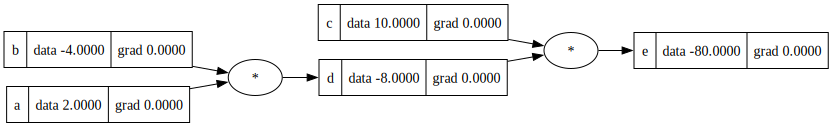

In [172]:
a=Value(2,label='a')
b=Value(-4,label='b')
c=Value(10,label='c')
d=a*b 
d.label='d'
e=d*c
e.label='e'

draw_dot(e)                                             

In [165]:
def lol():
    h=0.001
    a=Value(2,label='a')
    b=Value(-3,label='b')
    c=Value(7,label='c')
    d=a*b 
    d.data+=h
    d.label='d'
    e=d*c
    e.label='e'
    L1=e.data
    
    a=Value(2,label='a')
    b=Value(-4,label='b')
    c=Value(10+h,label='c')
    d=a*b 
    d.label='d'
    d.data+=h
    e=d*c
    e.label='e'
    L2=e.data
    print((L2-L1)/h)


In [234]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [235]:
x1w1

Value(-6.0,0)

In [236]:
o.grad=1

In [237]:
o.backward()

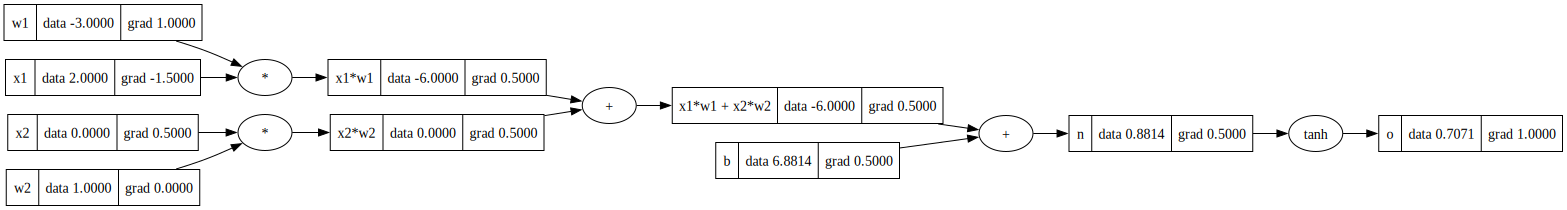

In [238]:
draw_dot(o)

In [ ]:
class Neuron:
    def __init__(self):
        

In [240]:
pip install torch

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 4.0 MB/s  0:02:21 eta 0:00:010:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.4 MB/s  0:02:43 eta 0:00:010:05:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.2 MB/s  0:00:27 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.4 MB/s  0:00:32 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 5.7 MB/s  0:00:10 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.7 MB/s  0:00:39 eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 5.7 MB/s  0:00:01m 6.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.9 MB/s  0:01:22 eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 4.9 MB/s  0:00:025.1 MB/s eta 0:00:0102
   ━━

In [ ]:
import tourch

In [ ]:
x1=tourch.Tensor([3.0])
x2=tourch.Tensor([4.0])
w1=tourch.Tensor([0.3])
w2=tourch.Tensor([0.5])
b=tourch.Tensor([0.6])

In [ ]:
x1.dtype

In [267]:
import random

class Neron():
    def __init__(self,nip):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nip)] 
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        out=sum([w*x  for w,x in zip(self.w,x)],self.b)
        act=out.tanh()
        return act;

class Layer():
    def __init__(self,nip,nout):
        self.nerons=[Neron(nip) for _ range(nout)]
    def __call__(self,x):
        return [n(x) for n is self.nerons]

class MLP():
    def __init__():
        

In [268]:
a=Neron(3)

In [269]:
a([3.0,3.0,3.0])

Value(-0.4082665229895653,0)

In [270]:
a.w

[Value(-0.1355662319175046,0),
 Value(0.6144950224617243,0),
 Value(-0.7435561059826543,0)]

In [271]:
a.b

Value(0.36035270384374796,0)

In [ ]:
clas